<a href="https://colab.research.google.com/github/rainforest01-coder/ESAA_files/blob/OB/week09_%ED%95%A9%EC%84%B1%EA%B3%B1%EC%8B%A0%EA%B2%BD%EB%A7%9D3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5.3 전이학습

일반적으로 합성곱 신경망 기반의 답러닝 모델을 제대로 훈련시키려면 많은 양의 데이터가 필요
합니다. 그런데 불행히도 충분히 큰 데이터셋을 얻는 것은 쉽지 않습니다. 큰 데이터셋을 확보하
려면 많은돈과시간이 필요하기 때문입니다.
이러한 현실적인 어려움을 해결한 것이 전이 학습처럼 아주 큰 데이터셋을 써서 훈련된 모댈의 가중치를 가져와 우리가 해결하려는
과제에 맞게 보정해서 사용하는 것을 의미합니다. 이때 아주 큰 데이터셋을 시용하여 훈련된 모댈
을 사전 훈련된 모댈(네트워크)이라고 합니다. 결과적으로 비교적 적은 수의 데이터를 가지고도
우리가 원하는 과제를 해결할 수 있습니다.

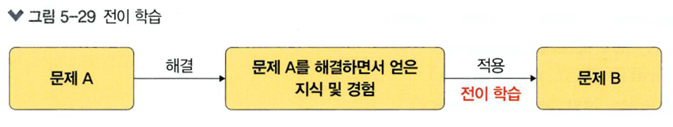

## 5.3.1 특성 추출 기법

ImageNet데이터셋으로 사전훈련된 모델을 가져온 후 마지막에 완전연결층 부분만 새로 만듦
> 학습시 완전 연결층만 학습하고 나머지 계층들을 학습되지 않도록함

* 합성곱층: 합성곱층과 풀링층으로 구성
* 데이터 분류기(완전연결층): 추출된 특성을 입력받아 최종적으로 이미지에 대한 클래스 분류

사전 훈련된 네트워크의 합성곱층(가중치 고정)에 새로운 데이터를 통과시키고， 그 출력을 데이터 분류기에서 훈련

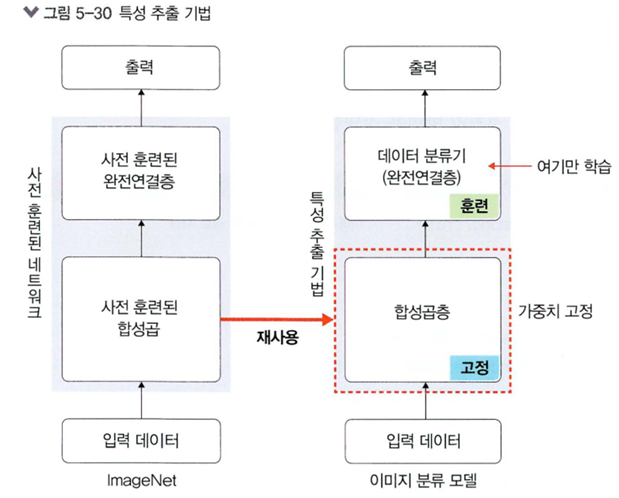


In [1]:
! pip install opencv-python

In [2]:
import os
import time
import copy
import cv2
import shutil
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [3]:
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

data_path = "/content/drive/MyDrive/ESAA/OB/과제/필사/데이터/gilbutITbook 080289 main chap05-data_catanddog/train"

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.ImageFolder(
    root=data_path,   # root= 추가
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    num_workers=8,
    shuffle=True
)

print(len(train_dataset))

385


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


torchvision.transfrom은 이미지 데이터를 변환하여 모델(네트워크)의 입력으로 시용할 수 있
게 변환해 줍니다.

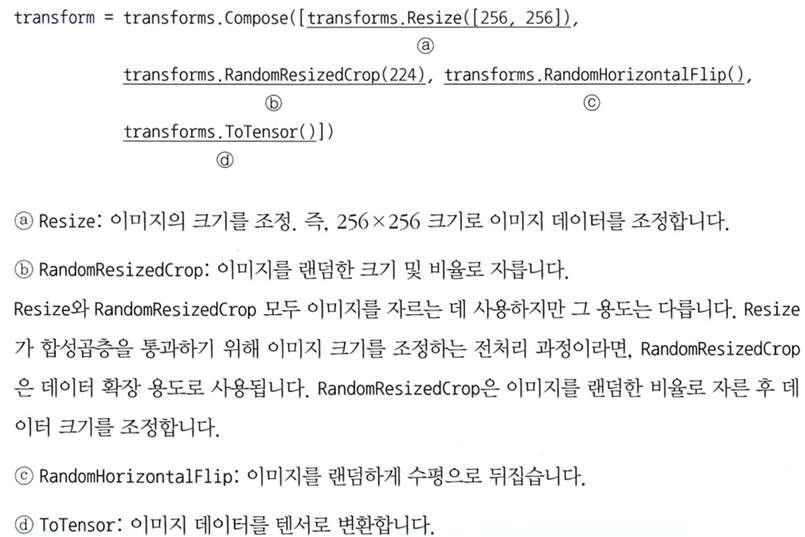

datasets.lmageFolder는 데이터로더가 데이터를 불러올 대상(혹은 경로)과 방법(띠nsfonn)(혹
은 전처리)을 정의

@ 첫 번째 파라미터: 불러올 데이터가 위치한 경로
@ transform: 이미지 데이터에 대한 전처리


@ 데이터로더는 데이터를 불러오는 부분으로 앞에서 정의한 ImageFolder(train_dataset)을 데
이터로더에 할당하는데， 이때 한 번에 불러올 데이터양을 결정하는 batch size를 지정합니다. 또
한， 추가적으로 데이터를 무작위로 섞을(shuff1e) 것인지도 설정합니다. 데이터로더에서 사용하는
파라미터는 다음과 같습니다.

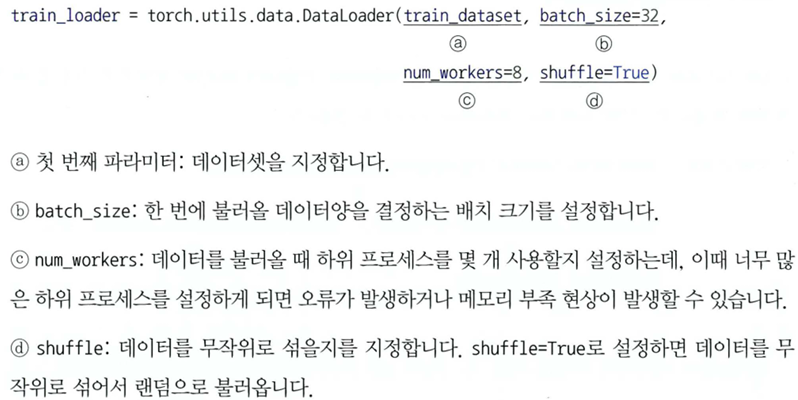

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


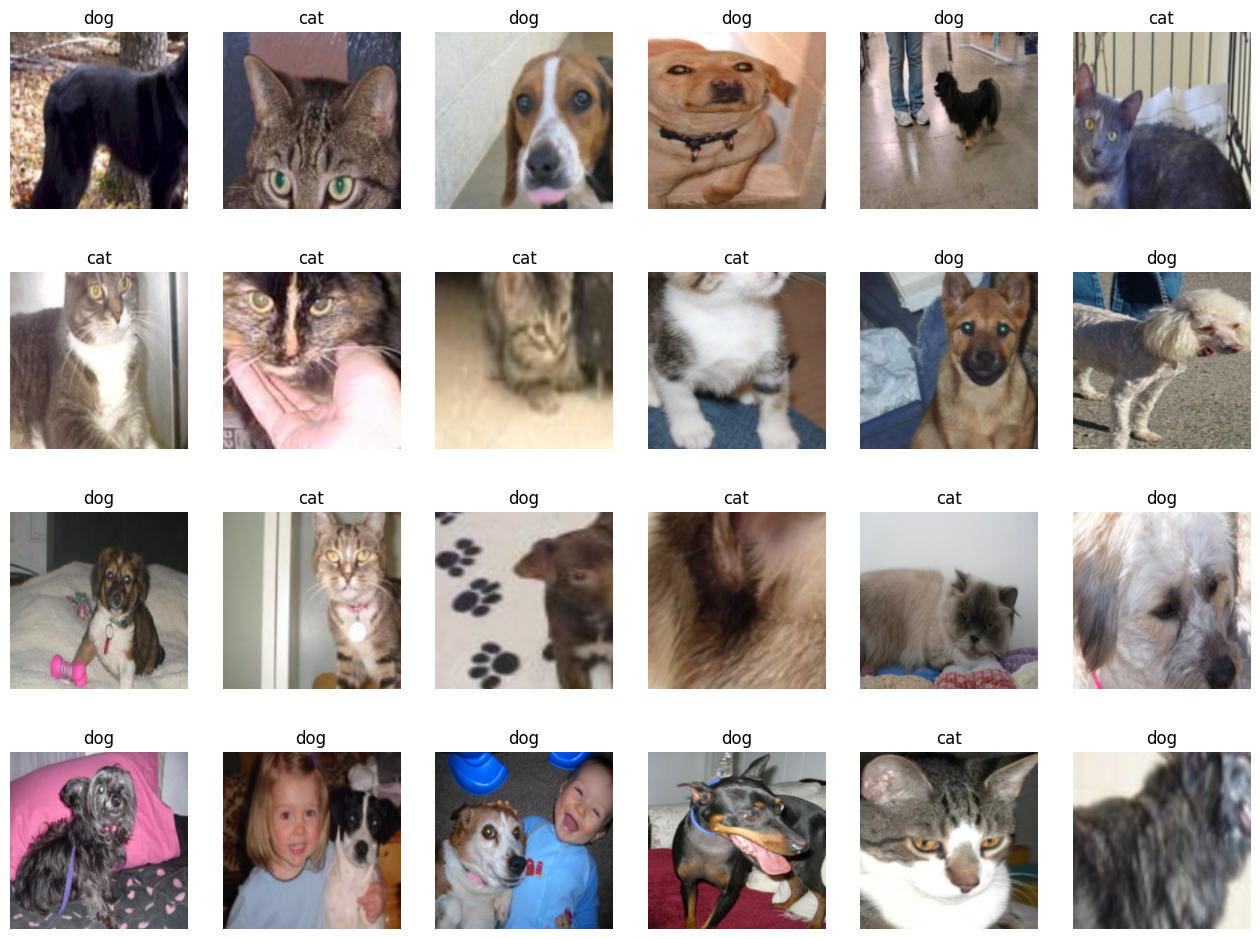

In [4]:
import numpy as np
samples,labels=next(iter(train_loader))
classes={0:'cat',1:'dog'}
fig=plt.figure(figsize=(16,24))
for i in range(24):
  a=fig.add_subplot(4,6,i+1)
  a.set_title(classes[labels[i].item()])
  a.axis('off')
  a.imshow(np.transpose(samples[i].numpy(),(1,2,0)))
plt.subplots_adjust(bottom=0.2,top=0.6,hspace=0)


반복자(i terator. for 구문과 같은 효과)를 사용하려면 iter()와 next()가 필요합니다.
i ter( )는 전달된 데이터의 반복자를 꺼내 반환하며 next()는 그 반복자가 다음에 출력해야 할 요
소를 반환합니다. 즉 iter()로 반복지를 구하고 그 반복자를 next()에 전달하여 차례대로 꺼낼
수 있습니다. 앞의 코드에서 반복지는 train_loader가 되기 때문에 train_loader에서 samp1es와
1abels의 값을 순차적으로 꺼내서 저장합니다. 간단허 정리하면 train_loader에서 데이터를 하
나씩 꺼내 오겠다는 의미입니다.


print(samples.shape)을통해 데이터의 형태를확인해 보면 torch.Size([32, 3, 224, 224])가
출력됩니다. 이 상태 그대로(np. transpose를 적용하지 않으면) ‘In\띠id shape β， 224, 224) for
image data'와 같은 오류가 발생합니다.
따라서 np.transpose(samples[i].numpy(), (1 ，2써))을사용해서 (224, 224, 3)과같은형태로
변환한 후 사용해야 합니다.

In [5]:
resnet18=models.resnet18(pretrained=True)#괄호안에 아무것도 없으면 무작위 가중치, 있으면 사전학습 모델 가중치 사용

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 71.6MB/s]


In [6]:
# 내려받은 ResNet18의 합성곱층을 사용하되 파라미터에 대해서는 학습을 하지 않도록 고정
def set_parameter_requires_grad(model,feature_extracting=True):
  if feature_extracting:
    for param in model.parameters():
      param.requires_grad=False
set_parameter_requires_grad(resnet18)

역전파 중 파라미터들에 대한 변화를 계산할 필요가 없음을 나타법니다. 즉， 모댈의 일부를 고
정하고 나머지를 학습하고자 할 때 requires_grad = False로 설정합니다. 이때 모댈의 일부는 합
성곱층(convolutïonal layer)과 풀링(pooling)층을 의미합니다.

내려받은 ResNet18의 마지막 부분에 완전연결층을 추가합니다. 추가된 완전연결층은 개와 고양
이 클래스를 분류하는 용도로 시용됩니다.

In [7]:
#ResNet18에 완전연결층 추가
resnet18.fc=nn.Linear(512,2) #2=class

In [8]:
#모댈의 따라미터 값 확인
for name,param in resnet18.named_parameters():
  if param.requires_grad:
    print(name,param.data)

fc.weight tensor([[ 0.0187, -0.0205, -0.0292,  ..., -0.0113,  0.0122,  0.0380],
        [ 0.0206,  0.0007, -0.0138,  ...,  0.0288, -0.0434,  0.0313]])
fc.bias tensor([0.0136, 0.0075])


In [9]:
model=models.resnet18(pretrained=True)
for param in model.parameters():
  param.requires_grad=False
model.fc=torch.nn.Linear(512,2)
for param in model.fc.parameters():
  param.requires_grad=True

optimizer=torch.optim.Adam(model.fc.parameters())
cost=torch.nn.CrossEntropyLoss()
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [10]:
#모델 학습을 위한 함수 생성
def train_model(model,dataloaders,criterion,optimizer,device,num_epochs=13,is_train=True):
  since=time.time()#컴퓨터의 현재시각
  acc_history=[]
  loss_history=[]
  best_acc=0.0
  for epoch in range(num_epochs):
    print('Epoch{}/{}'.format(epoch,num_epochs-1))
    print('-'*10)
    running_loss=0.0
    running_corrects=0

    for inputs,labels in dataloaders:
      inputs=inputs.to(device)
      labels=labels.to(device)
      model.to(device)
      optimizer.zero_grad()
      outputs=model(inputs)
      loss=criterion(outputs,labels)
      _,preds=torch.max(outputs,1)
      loss.backward()
      optimizer.step()
      running_loss+=loss.item()*inputs.size(0)
      running_corrects+=torch.sum(preds==labels.data)
    epoch_loss=running_loss/len(dataloaders.dataset)
    epoch_acc=running_corrects.double()/len(dataloaders.dataset)
    print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss,epoch_acc))
    if epoch_acc>best_acc:
      best_acc=epoch_acc

    acc_history.append(epoch_acc.item())
    loss_history.append(epoch_loss)
    torch.save(model.state_dict(),os.path.join('/content/drive/MyDrive/ESAA/OB/과제/필사/데이터/gilbutITbook 080289 main chap05-data_catanddog','{0:0=2d}.pth'.format(epoch)))
    print()
  time_elapsed=time.time()-since
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed//60,
                                                      time_elapsed%60))
  print('Best Acc: {:4f}'.format(best_acc))
  return acc_history,loss_history





In [11]:
params_to_update=[]
for name, param in resnet18.named_parameters():
  if param.requires_grad==True:
    params_to_update.append(param)
    print('\t',name)
optimizer=optim.Adam(params_to_update)

	 fc.weight
	 fc.bias


In [12]:
device=torch.device('cuda' if torch.cuda.is_available() else "cpu")
criterion=nn.CrossEntropyLoss()
train_acc_hist, train_loss_hist=train_model(resnet18,train_loader,criterion,optimizer,device)

Epoch0/12
----------
Loss: 0.5597 Acc: 0.7299

Epoch1/12
----------
Loss: 0.3787 Acc: 0.8649

Epoch2/12
----------
Loss: 0.3032 Acc: 0.8935

Epoch3/12
----------
Loss: 0.2532 Acc: 0.9273

Epoch4/12
----------
Loss: 0.2433 Acc: 0.9091

Epoch5/12
----------
Loss: 0.2185 Acc: 0.9091

Epoch6/12
----------
Loss: 0.1971 Acc: 0.9221

Epoch7/12
----------
Loss: 0.2252 Acc: 0.9117

Epoch8/12
----------
Loss: 0.2650 Acc: 0.8805

Epoch9/12
----------
Loss: 0.1719 Acc: 0.9429

Epoch10/12
----------
Loss: 0.2189 Acc: 0.9091

Epoch11/12
----------
Loss: 0.2428 Acc: 0.8909

Epoch12/12
----------
Loss: 0.1839 Acc: 0.9325

Training complete in 11m 44s
Best Acc: 0.942857


In [13]:
test_path='/content/drive/MyDrive/ESAA/OB/과제/필사/데이터/gilbutITbook 080289 main chap05-data_catanddog/test'

trasform=transforms.Compose(
    [
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
    ]
)
test_dataset=torchvision.datasets.ImageFolder(
    root=test_path,
    transform=transform
)
test_loader=torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

print(len(test_dataset))

98


In [23]:
import glob
def eval_model(model,dataloaders,device):
  since=time.time()
  acc_history=[]
  best_acc=0.0

  saved_models=glob.glob('/content/drive/MyDrive/ESAA/OB/과제/필사/데이터/gilbutITbook 080289 main chap05-data_catanddog/'+'*.pth')
  saved_models.sort()
  print('saved_model',saved_models)
  for model_path in saved_models:
    print('Loading model', model_path)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    model.to(device)
    running_corrects=0
    for inputs,labels in dataloaders:
      inputs=inputs.to(device)
      labels=labels.to(device)
      with torch.no_grad():
        outputs=model(inputs)
        _,preds=torch.max(outputs.data,1)
        preds[preds>=0.5]=1
        preds[preds<0.5]=0
        running_corrects+=preds.eq(labels.cpu()).int().sum()
    epoch_acc=running_corrects.double()/len(dataloaders.dataset)
    print('Acc:{:.4f}'.format(epoch_acc))
    if epoch_acc>best_acc:
      best_acc=epoch_acc
    acc_history.append(epoch_acc.item())
    print()
  time_elapsed=time.time()-since
  print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed//60,time_elapsed%60))
  print('Best Acc: {:4f}'.format(best_acc))

  return acc_history


In [24]:
val_acc_hist=eval_model(resnet18,test_loader,device)

saved_model ['/content/drive/MyDrive/ESAA/OB/과제/필사/데이터/gilbutITbook 080289 main chap05-data_catanddog/00.pth', '/content/drive/MyDrive/ESAA/OB/과제/필사/데이터/gilbutITbook 080289 main chap05-data_catanddog/01.pth', '/content/drive/MyDrive/ESAA/OB/과제/필사/데이터/gilbutITbook 080289 main chap05-data_catanddog/02.pth', '/content/drive/MyDrive/ESAA/OB/과제/필사/데이터/gilbutITbook 080289 main chap05-data_catanddog/03.pth', '/content/drive/MyDrive/ESAA/OB/과제/필사/데이터/gilbutITbook 080289 main chap05-data_catanddog/04.pth', '/content/drive/MyDrive/ESAA/OB/과제/필사/데이터/gilbutITbook 080289 main chap05-data_catanddog/05.pth', '/content/drive/MyDrive/ESAA/OB/과제/필사/데이터/gilbutITbook 080289 main chap05-data_catanddog/06.pth', '/content/drive/MyDrive/ESAA/OB/과제/필사/데이터/gilbutITbook 080289 main chap05-data_catanddog/07.pth', '/content/drive/MyDrive/ESAA/OB/과제/필사/데이터/gilbutITbook 080289 main chap05-data_catanddog/08.pth', '/content/drive/MyDrive/ESAA/OB/ᄀ

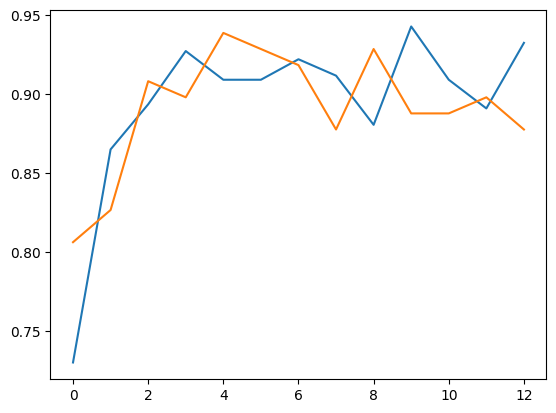

In [26]:
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

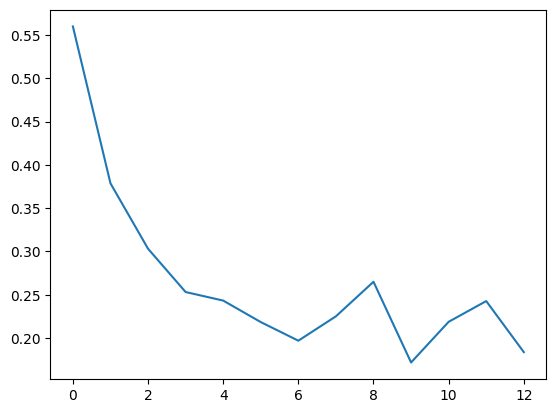

In [17]:
plt.plot(train_loss_hist)
plt.show()

In [18]:
def im_convert(tensor):
  image=tensor.clone().detach().numpy()
  image=image.transpose(1,2,0)
  image=image*(np.array((0.5,0.5,0.5))+np.array((0.5,0.5,0.5)))
  image=image.clip(0,1)
  return image

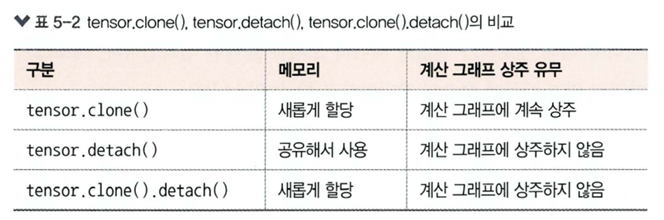

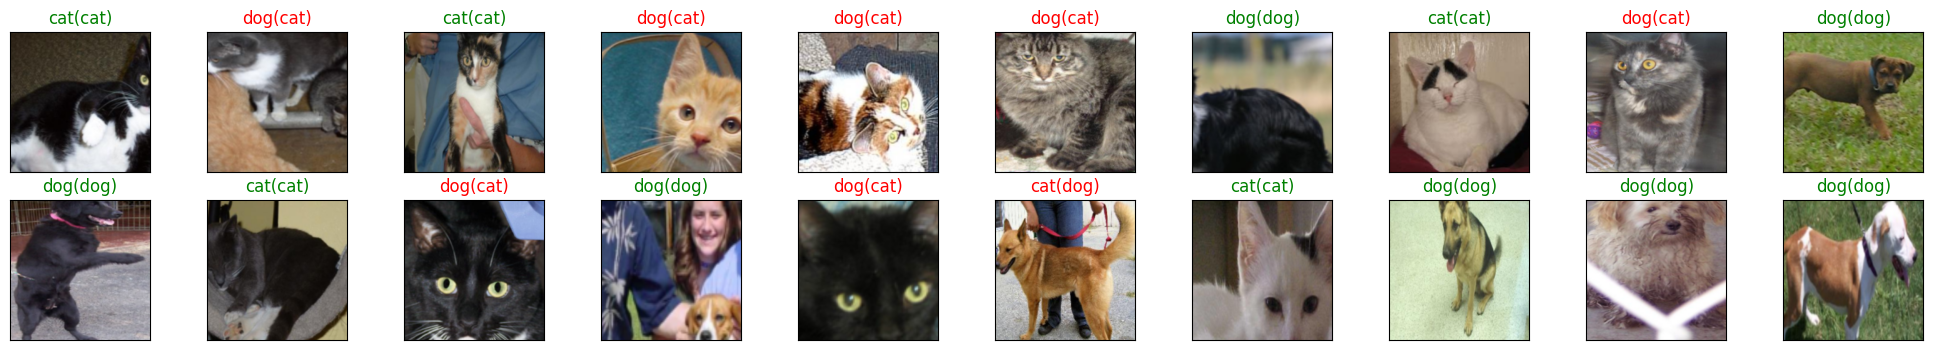

<Figure size 640x480 with 0 Axes>

In [19]:
classes={0:'cat',1:'dog'}
dataiter=iter(test_loader)
images,labels=next(dataiter)
output=model(images)
_,preds=torch.max(output,1)
fig=plt.figure(figsize=(25,4))
for idx in np.arange(20):
  ax=fig.add_subplot(2,10,idx+1,xticks=[],yticks=[])
  plt.imshow(im_convert(images[idx]))
  a.set_title(classes[labels[i].item()])
  ax.set_title("{}({})".format(str(classes[preds[idx].item()]),str(classes[labels[idx].item()])),color=("green" if preds[idx]==labels[idx] else "red"))
plt.show()
plt.subplots_adjust(bottom=0.2,top=0.6,hspace=0)


### 5.3.2 미세 조정 기법

미세 조정(fine-runing) 기법은 특성 추출 기법에서 더 나아가 사전 훈련된 모댈과 합성곱층， 데이
터 분류기의 가중치를 업데이트하여 훈련시키는 방식입니다. 특성 추출은 목표 특성을 잘 추출했
다는 전제하에 좋은 성능을 낼 수 있습니다. 특성이 잘못 추출되었다면(예를 들어 ImageNet 데
이터셋의 이미지 특징과 전자상거래 물품의 이미지 특정이 다르다면) 미세 조정 기법으로 새로운
(전자상거래) 이미지 데이터를 시용하여 네트워크의 가중치를 업데이트해서 특성을 다시 추출할
수 있습니다. 즉， 사전 학습된 모델을 목적에 맞게 재학습시키거나 학습된 가중치의 일부를 재학
습시키는것입니다.


* 데이터셋이 크고 사전 훈련된 모델과 유사성이 작을 경우: 모댈 전체를 재학습시겁니다. 데이터
셋 크기가 크기 때문에 재학습시키는 것이 좋은 전략입니다.


* 데이터셋이 크고 사전 훈련된 모델과 유사성이 클 경우: 합성곱층의 뒷부분(완전연결층과 가까
운 부분)과 데이터 분류기를 학습시겁니다. 데이터셋이 유사하기 때문에 전체를 학습시키는
228
것보다는 강한 특징이 나타나는 합성곱층의 뒷부분과 데이터 분류기만 새로 학습하더라도 최적의 성능을 낼 수 있습니다.

* 데이터셋이 작고 사전 훈련된 모델과 유사성이 작을 경우: 합성곱층의 일부분과 데이터 분류기
를 학습시겁니다. 데이터가 적기 때문에 일부 계층에 미세 조정 기법을 적용한다고 해도 효
과가 없을 수 있습니다. 따라서 합성곱층 중 어디까지 새로 학습시켜야 할지 적당히 설정해
주어야합니다.
* 데이터셋이 작고 사전 훈련된 모델과 유사성이 클 경우: 데이터 분류기만 학습시겁니다. 데이터
가 적기 때문에 많은 계층에 미세 조정 기법을 적용하면 과적합이 발생할 수 있습니다. 따라
서 최종 데이터 분류기 인 완전연결층에 대해서만 미세 조정 기법을 적용합니다.